In [ ]:
import pandas as pd
import glob
import os

# 1. Đường dẫn tới thư mục chứa 2525 file CSV (Thay đổi đường dẫn này cho đúng với máy của bạn)
folder_path = r'./clinical_ProteinGym_substitutions' 
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

print(f"Đang tiến hành gộp {len(all_files)} file...")

df_list = []
for file in all_files:
    try:
        df = pd.read_csv(file)
        df_list.append(df)
    except Exception as e:
        print(f"Lỗi đọc file {file}: {e}")

# Gộp tất cả thành 1 DataFrame duy nhất
master_df = pd.concat(df_list, ignore_index=True)

# 2. Xóa cột Index thừa (cột 'Unnamed: 0' nếu có)
if 'Unnamed: 0' in master_df.columns:
    master_df = master_df.drop(columns=['Unnamed: 0'])

# 3. Chuẩn hóa cột Label (DMS_bin_score -> label)
master_df.rename(columns={'DMS_bin_score': 'label'}, inplace=True)
# Đưa về chữ thường và cắt khoảng trắng
master_df['label'] = master_df['label'].astype(str).str.lower().str.strip()
# Chuyển đổi 'pathogenic' thành 'patho' cho đúng format
master_df['label'] = master_df['label'].replace({'pathogenic': 'patho'})

# 4. Tạo chuỗi đầu vào chuẩn cho TransVar (Định dạng HGVS: MãProtein:p.ĐộtBiến)
# Ví dụ: NP_00000:p.R29L
master_df['transvar_input'] = master_df['protein'] + ':p.' + master_df['mutant']

# 5. Lưu lại thành 2 file
# File thứ nhất: Danh sách đầu vào để đưa cho TransVar chạy (chỉ có 1 cột)
master_df['transvar_input'].to_csv('transvar_input.txt', index=False, header=False)

# File thứ hai: Bảng Master lưu trữ tạm thời để ghép lại ở bước cuối
master_df.to_csv('ProteinGym_Merged_Temp.csv', index=False)

print(f"Hoàn tất! Đã lưu bảng master với {len(master_df)} dòng.")

In [ ]:
import pandas as pd
import requests
import json
import time

# Từ điển chuyển đổi axit amin 1 chữ sang 3 chữ (chuẩn VEP)
aa_map = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'E': 'Glu', 'Q': 'Gln', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val'
}

def convert_to_hgvs(protein, mutant):
    try:
        ref_aa_1 = mutant[0]
        alt_aa_1 = mutant[-1]
        pos = mutant[1:-1]
        ref_aa_3 = aa_map[ref_aa_1.upper()]
        alt_aa_3 = aa_map[alt_aa_1.upper()]
        # Định dạng chuẩn: ID_Protein:p.ThamChieu_ToaDo_DotBien
        return f"{protein}:p.{ref_aa_3}{pos}{alt_aa_3}"
    except:
        return None

print("1. Đang đọc dữ liệu từ ProteinGym_Merged_Temp.csv...")
df = pd.read_csv('ProteinGym_Merged_Temp.csv')

# Tạo cột HGVS để nạp vào API
df['hgvs'] = df.apply(lambda row: convert_to_hgvs(row['protein'], str(row['mutant'])), axis=1)
df = df.dropna(subset=['hgvs'])
hgvs_list = df['hgvs'].tolist()

print(f"2. Chuẩn bị truy vấn VEP API cho {len(hgvs_list)} đột biến...")
server = "https://rest.ensembl.org"
ext = "/vep/human/hgvs"
headers = {"Content-Type": "application/json", "Accept": "application/json"}

def fetch_vep_batch(batch):
    data = {"hgvs_notations": batch}
    # Gửi request lên VEP API
    response = requests.post(server + ext, headers=headers, data=json.dumps(data))
    if not response.ok:
        response.raise_for_status()
    return response.json()

results_dict = {}
batch_size = 200
total_batches = (len(hgvs_list) // batch_size) + 1

for i in range(total_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, len(hgvs_list))
    batch = hgvs_list[start_idx:end_idx]
    if not batch:
        break
    
    print(f" => Đang xử lý batch {i+1}/{total_batches}...")
    try:
        res = fetch_vep_batch(batch)
        for item in res:
            try:
                hgvs_key = item['input']
                # Trích xuất 4 tọa độ chính
                chrom = str(item['seq_region_name'])
                if not chrom.startswith('chr'):
                    chrom = f"chr{chrom}"
                pos = item['start']
                alleles = item['allele_string'].split('/')
                ref = alleles[0]
                alt = alleles[1] if len(alleles) > 1 else '-'
                
                results_dict[hgvs_key] = {'chrom': chrom, 'pos': pos, 'ref': ref, 'alt': alt}
            except KeyError:
                continue
    except Exception as e:
        print(f" [!] Lỗi ở batch {i+1}: {e}")
    
    # Nghỉ 0.15s giữa các lần gọi để không bị chặn IP
    time.sleep(0.15) 

print("\n3. Đang hợp nhất kết quả tọa độ vào bảng dữ liệu...")
df['chrom'] = df['hgvs'].map(lambda x: results_dict.get(x, {}).get('chrom', None))
df['pos'] = df['hgvs'].map(lambda x: results_dict.get(x, {}).get('pos', None))
df['ref'] = df['hgvs'].map(lambda x: results_dict.get(x, {}).get('ref', None))
df['alt'] = df['hgvs'].map(lambda x: results_dict.get(x, {}).get('alt', None))

# Lọc bỏ các dòng mà VEP không tìm thấy tọa độ DNA
df_final = df.dropna(subset=['chrom', 'pos'])

# Sắp xếp lại thứ tự ưu tiên 9 cột theo chuẩn nhóm
cols = ['chrom', 'pos', 'ref', 'alt', 'label', 'protein', 'protein_sequence', 'mutant', 'mutated_sequence']
df_final = df_final[cols]

# Ép kiểu cho cột pos về số nguyên
df_final['pos'] = df_final['pos'].astype(int)

df_final.to_csv('ProteinGym_Clinical_Processed.csv', index=False)
print(f"Hoàn tất! File chuẩn cuối cùng đã được lưu: ProteinGym_Clinical_Processed.csv ({len(df_final)} dòng)")

Đang nạp dữ liệu...

1. DATASET OVERVIEW (TỔNG QUAN)
Shape (Số dòng, Số cột): (55744, 10)

Danh sách các cột (Columns):
['chrom', 'pos', 'ref', 'alt', 'label', 'protein', 'protein_sequence', 'mutant', 'mutated_sequence', 'seq_length']

Kiểu dữ liệu (Data types):
chrom               object
pos                  int64
ref                 object
alt                 object
label               object
protein             object
protein_sequence    object
mutant              object
mutated_sequence    object
seq_length           int64
dtype: object

Số lượng giá trị duy nhất (Unique values):
chrom                  28
pos                 52667
ref                     6
alt                     7
label                   2
protein              2523
protein_sequence     2523
mutant              39963
mutated_sequence    55744
seq_length           1160
dtype: int64

2. DATA QUALITY (CHẤT LƯỢNG DỮ LIỆU)
Số lượng Missing values ở mỗi cột:
chrom               0
pos                 0
ref                

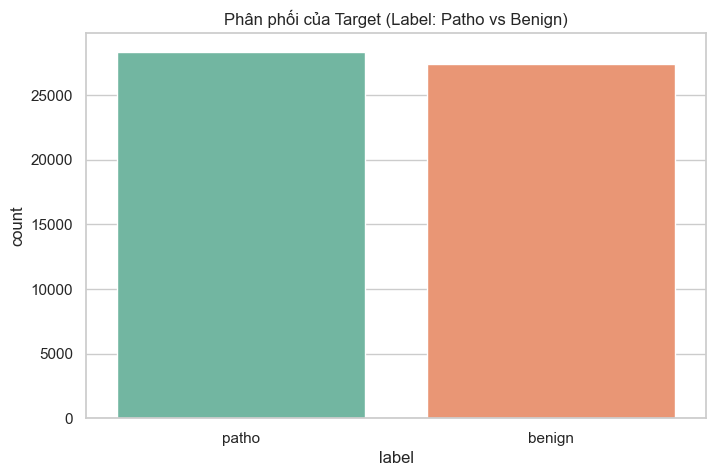

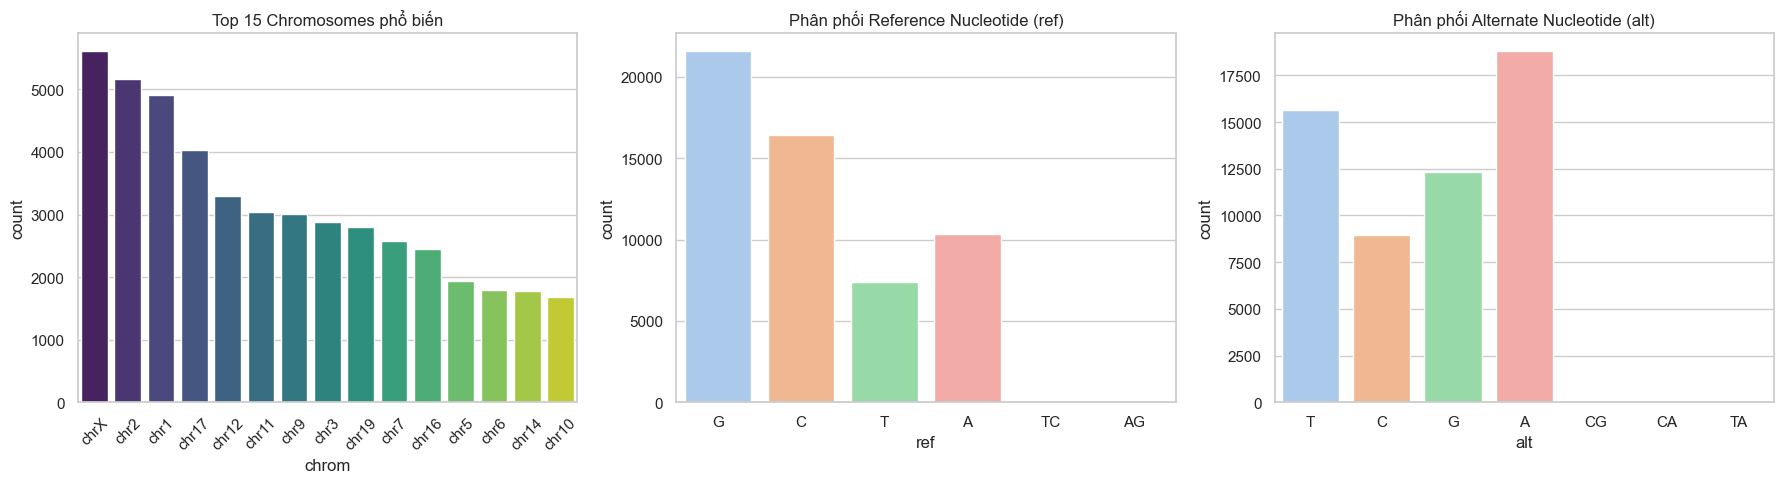

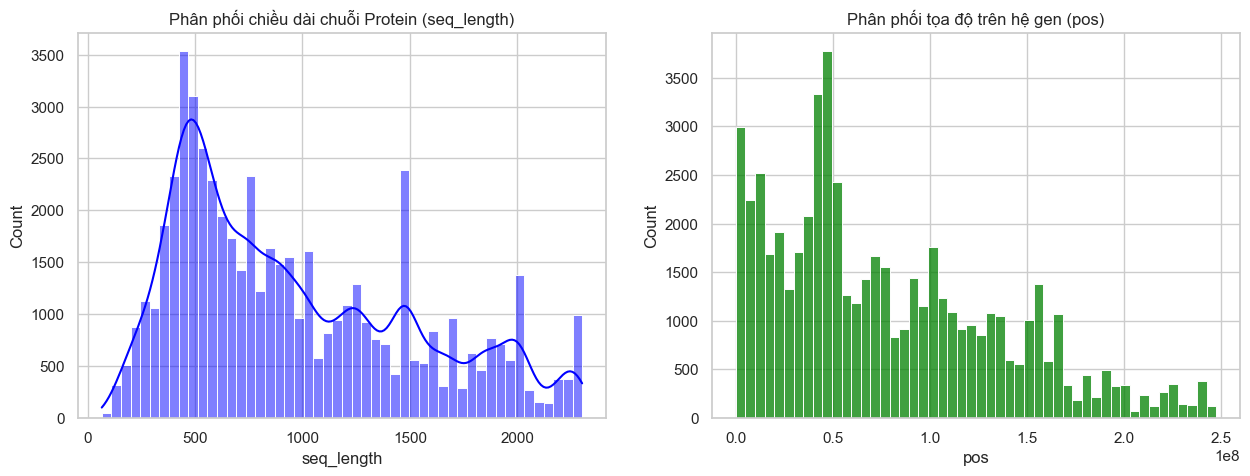


4. OUTLIER ANALYSIS (PHÂN TÍCH NGOẠI LAI)


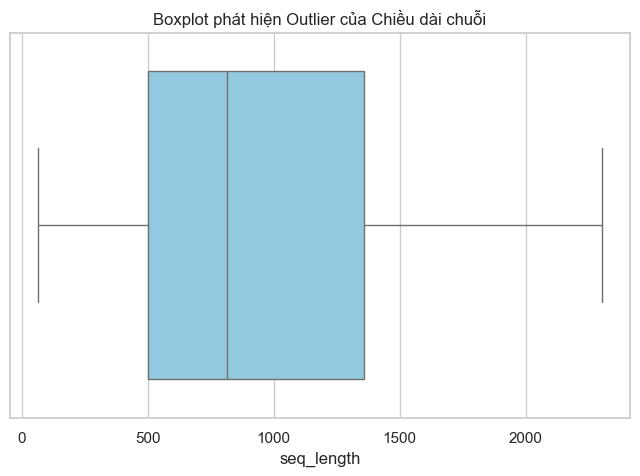

Số lượng Outliers theo IQR (seq_length): 0
Số lượng Outliers theo Z-score > 3 (seq_length): 0

5. BIVARIATE ANALYSIS (PHÂN TÍCH SONG BIẾN)


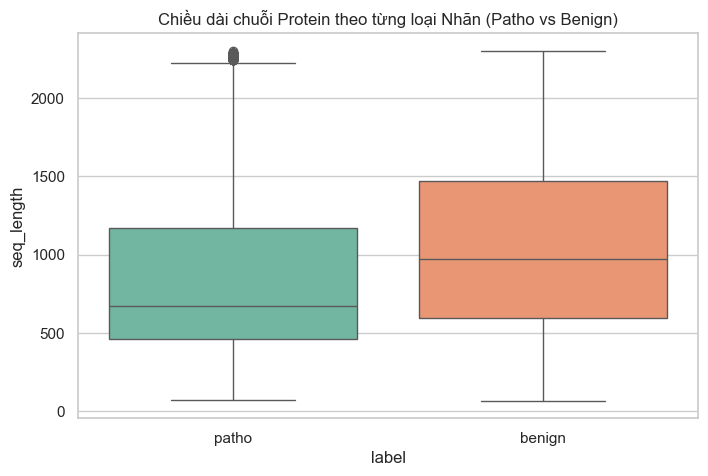

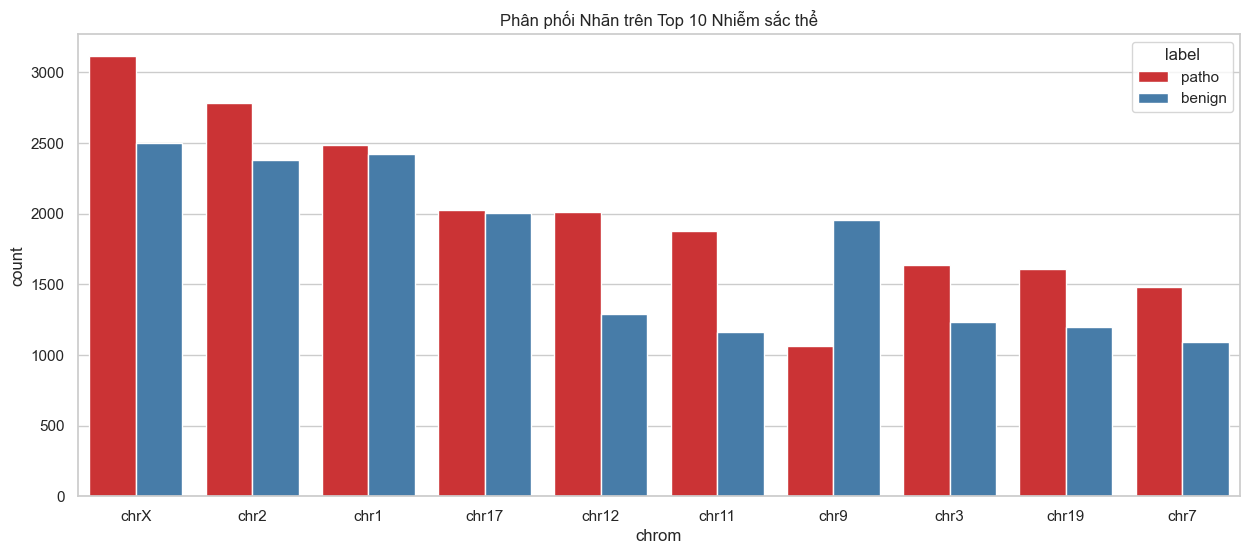


6. CORRELATION ANALYSIS (PHÂN TÍCH TƯƠNG QUAN)


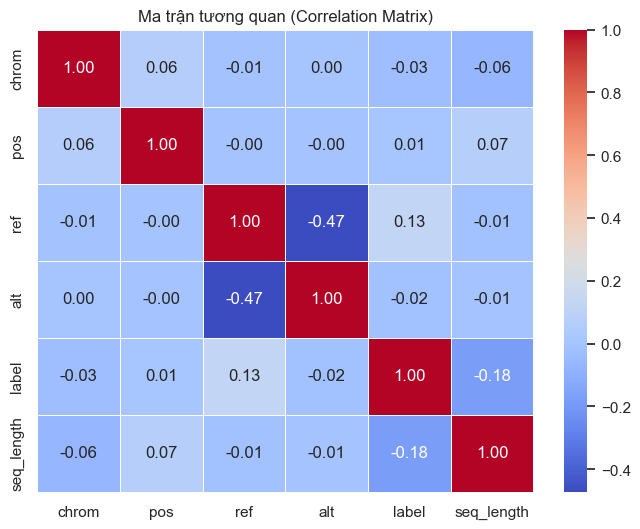


7. GENE-LEVEL ANALYSIS (THỐNG KÊ THEO GEN)
Tổng số Gen độc nhất (Unique Genes) trong bộ dữ liệu: 39963

Top 15 Gen có nhiều biến thể nhất (Chi tiết số lượng Lành tính/Gây bệnh):
label   total_variants  patho  benign
mutant                               
R46Q                10      9       1
R389H                9      5       4
A3V                  9      0       9
R325Q                9      3       6
A413T                8      0       8
R170Q                8      6       2
R105Q                8      4       4
R233H                8      6       2
R92Q                 8      5       3
R280H                8      6       2
A2V                  8      2       6
R104Q                7      5       2
A234T                7      2       5
R121W                7      5       2
P4L                  7      0       7


<Figure size 1400x700 with 0 Axes>

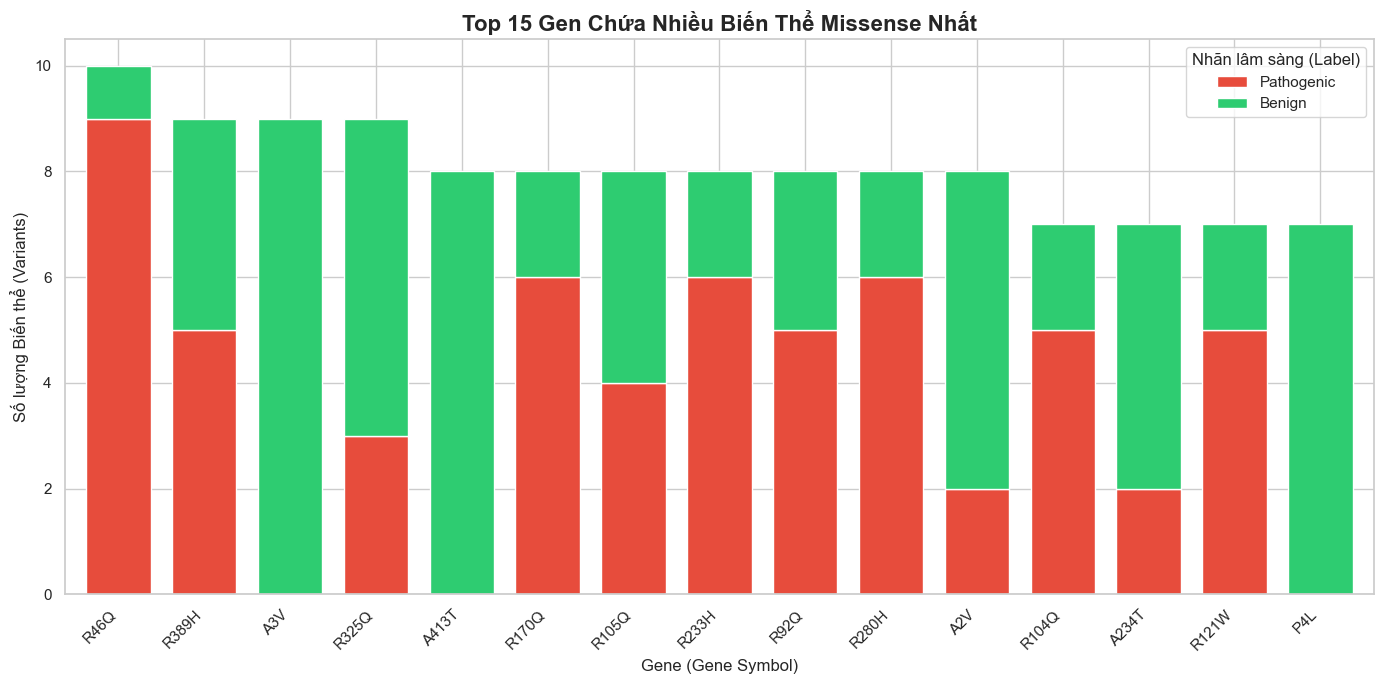


------------------------------
INSIGHTS TỪ PHÂN TÍCH GEN:
- Số lượng Gen chỉ toàn biến thể Gây bệnh (100% Patho): 17664 gen.
- Số lượng Gen chỉ toàn biến thể Lành tính (100% Benign): 17221 gen.

------------------------------
THỐNG KÊ TỶ LỆ PATHOGENIC TRUNG BÌNH CỦA CÁC GEN:
- Trung bình cộng tỷ lệ đột biến Gây bệnh (Pathogenic) trên mỗi Gen: 50.62%
- Trung vị (Median) tỷ lệ đột biến Gây bệnh trên mỗi Gen: 50.00%

8. DATA INSIGHTS (GỢI Ý RÚT RA KẾT LUẬN TỪ ĐỒ THỊ)

[HƯỚNG DẪN DÀNH CHO NHÓM ĐỂ ĐỌC ĐỒ THỊ]:
- Target Distribution: Kiểm tra sự mất cân bằng nhãn. Nếu lệch quá nhiều, Lớp Hòa trộn Đa chiến lược cần đổi hàm loss (như Focal Loss) hoặc dùng kỹ thuật lấy mẫu (SMOTE).
- Numerical Distribution: Đột biến chủ yếu xảy ra ở protein ngắn hay dài? Nếu có quá nhiều protein > 1000 amino acids, việc trích xuất cửa sổ 101 aa của Ensembl VEP là cực kỳ hợp lý để tiết kiệm bộ nhớ.
- Categorical vs Categorical: Các đột biến Pathogenic có tập trung bất thường ở một vài nhiễm sắc thể nhất định (n

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Đang nạp dữ liệu...")
# Lưu ý: Hãy đảm bảo đường dẫn trỏ đúng tới file đã xử lý ở bước trước
df = pd.read_csv(r"D:\Study\AiTa_Lab_Research\ProteinGym_Clinical_Processed.csv")

# Feature Engineering nhẹ để có thêm biến số học (Numerical) cho phân tích
df['seq_length'] = df['protein_sequence'].apply(len)
# Đảm bảo cột pos là dạng số
df['pos'] = pd.to_numeric(df['pos'], errors='coerce')

print("\n" + "="*50)
print("1. DATASET OVERVIEW (TỔNG QUAN)")
print("="*50)
print(f"Shape (Số dòng, Số cột): {df.shape}")
print("\nDanh sách các cột (Columns):")
print(df.columns.tolist())
print("\nKiểu dữ liệu (Data types):")
print(df.dtypes)
print("\nSố lượng giá trị duy nhất (Unique values):")
print(df.nunique())

print("\n" + "="*50)
print("2. DATA QUALITY (CHẤT LƯỢNG DỮ LIỆU)")
print("="*50)
print("Số lượng Missing values ở mỗi cột:")
print(df.isnull().sum())
print(f"\nSố lượng dòng trùng lặp (Duplicates): {df.duplicated().sum()}")

print("\n" + "="*50)
print("3. UNIVARIATE ANALYSIS (PHÂN TÍCH ĐƠN BIẾN)")
print("="*50)
# 3.1 Target Distribution (Phân phối nhãn)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Phân phối của Target (Label: Patho vs Benign)')
plt.show()

# 3.2 Categorical Distribution (Nhiễm sắc thể & Nucleotide)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, x='chrom', order=df['chrom'].value_counts().index[:15], ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 Chromosomes phổ biến')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='ref', ax=axes[1], palette='pastel')
axes[1].set_title('Phân phối Reference Nucleotide (ref)')

sns.countplot(data=df, x='alt', ax=axes[2], palette='pastel')
axes[2].set_title('Phân phối Alternate Nucleotide (alt)')
plt.tight_layout()
plt.show()

# 3.3 Numerical distribution (Phân phối chiều dài chuỗi và Tọa độ)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['seq_length'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Phân phối chiều dài chuỗi Protein (seq_length)')

sns.histplot(df['pos'], bins=50, kde=False, ax=axes[1], color='green')
axes[1].set_title('Phân phối tọa độ trên hệ gen (pos)')
plt.show()

print("\n" + "="*50)
print("4. OUTLIER ANALYSIS (PHÂN TÍCH NGOẠI LAI)")
print("="*50)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['seq_length'], color='skyblue')
plt.title('Boxplot phát hiện Outlier của Chiều dài chuỗi')
plt.show()

# Tính IQR & Z-score cho seq_length
Q1 = df['seq_length'].quantile(0.25)
Q3 = df['seq_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['seq_length'] < lower_bound) | (df['seq_length'] > upper_bound)]
print(f"Số lượng Outliers theo IQR (seq_length): {len(outliers_iqr)}")

z_scores = np.abs(stats.zscore(df['seq_length'].dropna()))
outliers_z = len(np.where(z_scores > 3)[0])
print(f"Số lượng Outliers theo Z-score > 3 (seq_length): {outliers_z}")

print("\n" + "="*50)
print("5. BIVARIATE ANALYSIS (PHÂN TÍCH SONG BIẾN)")
print("="*50)
# Numerical ↔ Categorical (seq_length vs label)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='seq_length', palette='Set2')
plt.title('Chiều dài chuỗi Protein theo từng loại Nhãn (Patho vs Benign)')
plt.show()

# Categorical ↔ Categorical (Nhiễm sắc thể vs Nhãn)
plt.figure(figsize=(15, 6))
top_chroms = df['chrom'].value_counts().index[:10]
sns.countplot(data=df[df['chrom'].isin(top_chroms)], x='chrom', hue='label', palette='Set1', order=top_chroms)
plt.title('Phân phối Nhãn trên Top 10 Nhiễm sắc thể')
plt.show()

print("\n" + "="*50)
print("6. CORRELATION ANALYSIS (PHÂN TÍCH TƯƠNG QUAN)")
print("="*50)
# Để làm Correlation Matrix, ta cần mã hóa (Label Encoding) các biến categorical
df_encoded = df[['chrom', 'pos', 'ref', 'alt', 'label', 'seq_length']].copy()
for col in ['chrom', 'ref', 'alt', 'label']:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

corr_matrix = df_encoded.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan (Correlation Matrix)')
plt.show()

print("\n" + "="*50)
print("7. GENE-LEVEL ANALYSIS (THỐNG KÊ THEO GEN)")
print("="*50)

# Kiểm tra xem cột mutant có tồn tại và có bị thiếu dữ liệu không
if 'mutant' in df.columns:
    missing_genes = df['mutant'].isnull().sum()
    if missing_genes > 0:
        print(f"Cảnh báo: Có {missing_genes} dòng bị thiếu thông tin Gen. Đang tiến hành loại bỏ để thống kê...")
        df_gene = df.dropna(subset=['mutant'])
    else:
        df_gene = df.copy()

    # Sử dụng pd.crosstab để đếm số lượng label (patho/benign) theo từng gene_info
    gene_stats = pd.crosstab(df_gene['mutant'], df_gene['label'])

    # Đảm bảo bảng có đủ cột để tránh lỗi
    if 'benign' not in gene_stats.columns:
        gene_stats['benign'] = 0
    if 'patho' not in gene_stats.columns:
        gene_stats['patho'] = 0

    # Tính tổng số biến thể của từng gen
    gene_stats['total_variants'] = gene_stats['benign'] + gene_stats['patho']

    # Sắp xếp danh sách theo tổng số biến thể giảm dần
    gene_stats = gene_stats.sort_values(by='total_variants', ascending=False)

    print(f"Tổng số Gen độc nhất (Unique Genes) trong bộ dữ liệu: {len(gene_stats)}")
    print("\nTop 15 Gen có nhiều biến thể nhất (Chi tiết số lượng Lành tính/Gây bệnh):")
    print(gene_stats[['total_variants', 'patho', 'benign']].head(15))

    # Trực quan hóa bằng Stacked Bar Chart
    plt.figure(figsize=(14, 7))
    top_15_genes = gene_stats.head(15)

    # Vẽ biểu đồ thanh xếp chồng
    top_15_genes[['patho', 'benign']].plot(
        kind='bar', 
        stacked=True, 
        color=['#e74c3c', '#2ecc71'], # Đỏ cho Patho, Xanh lá cho Benign
        figsize=(14, 7),
        width=0.75
    )

    plt.title('Top 15 Gen Chứa Nhiều Biến Thể Missense Nhất', fontsize=16, fontweight='bold')
    plt.xlabel('Gene (Gene Symbol)', fontsize=12)
    plt.ylabel('Số lượng Biến thể (Variants)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Nhãn lâm sàng (Label)', labels=['Pathogenic', 'Benign'])
    plt.tight_layout()
    plt.show()

    # Thống kê sâu: Tìm các Gen "Cực đoan" (Toàn Patho hoặc Toàn Benign)
    only_patho_genes = gene_stats[(gene_stats['patho'] > 0) & (gene_stats['benign'] == 0)]
    only_benign_genes = gene_stats[(gene_stats['benign'] > 0) & (gene_stats['patho'] == 0)]

    print("\n" + "-"*30)
    print("INSIGHTS TỪ PHÂN TÍCH GEN:")
    print(f"- Số lượng Gen chỉ toàn biến thể Gây bệnh (100% Patho): {len(only_patho_genes)} gen.")
    print(f"- Số lượng Gen chỉ toàn biến thể Lành tính (100% Benign): {len(only_benign_genes)} gen.")

    # ==========================================
    # BỔ SUNG: TÍNH TRUNG BÌNH CỘNG PHẦN TRĂM PATHOGENIC
    # ==========================================
    # Bước 1: Tính % Pathogenic cho từng Gen riêng biệt
    gene_stats['patho_percentage'] = (gene_stats['patho'] / gene_stats['total_variants']) * 100
    
    # Bước 2: Tính trung bình cộng của các tỷ lệ % này trên toàn bộ tập Gen
    mean_patho_percentage = gene_stats['patho_percentage'].mean()
    median_patho_percentage = gene_stats['patho_percentage'].median()
    
    print("\n" + "-"*30)
    print("THỐNG KÊ TỶ LỆ PATHOGENIC TRUNG BÌNH CỦA CÁC GEN:")
    print(f"- Trung bình cộng tỷ lệ đột biến Gây bệnh (Pathogenic) trên mỗi Gen: {mean_patho_percentage:.2f}%")
    print(f"- Trung vị (Median) tỷ lệ đột biến Gây bệnh trên mỗi Gen: {median_patho_percentage:.2f}%")

else:
    print("Không tìm thấy cột 'gene_info' trong tập dữ liệu. Vui lòng kiểm tra lại quá trình tiền xử lý!")

print("\n" + "="*50)
print("8. DATA INSIGHTS (GỢI Ý RÚT RA KẾT LUẬN TỪ ĐỒ THỊ)")
print("="*50)
print("""
[HƯỚNG DẪN DÀNH CHO NHÓM ĐỂ ĐỌC ĐỒ THỊ]:
- Target Distribution: Kiểm tra sự mất cân bằng nhãn. Nếu lệch quá nhiều, Lớp Hòa trộn Đa chiến lược cần đổi hàm loss (như Focal Loss) hoặc dùng kỹ thuật lấy mẫu (SMOTE).
- Numerical Distribution: Đột biến chủ yếu xảy ra ở protein ngắn hay dài? Nếu có quá nhiều protein > 1000 amino acids, việc trích xuất cửa sổ 101 aa của Ensembl VEP là cực kỳ hợp lý để tiết kiệm bộ nhớ.
- Categorical vs Categorical: Các đột biến Pathogenic có tập trung bất thường ở một vài nhiễm sắc thể nhất định (như chrX) không?
- Phân tích Gen (Gene-Level): Sự chênh lệch giữa Trung bình cộng (%) và Trung vị (%) của nhãn Pathogenic sẽ chỉ ra liệu bộ dữ liệu có bị thiên vị phân bố (skewed distribution) giữa các gen hay không.
""")